# Nightlights around drug production areas

This notebook compares **night-time lights (NTL)** around known and suspected drug production locations in Syria, using factory cells as the treatment group and neighboring cells as a comparison group.

## Notebook workflow

1. **Load and clean the factory dataset**  
   Import the drug production site spreadsheet, fix inconsistent location names, and identify which sites have exact coordinates.

2. **Load spatial boundaries**  
   Read Syria admin boundary shapefiles to provide geographic context for mapping and aggregation.

3. **Create spatial representations of sites**  
   Convert point locations into H3 grid cells and generate hexagon geometries for each factory location.

4. **Construct the comparison group**  
   Build the immediate neighboring H3 cells around each factory site to represent surrounding non-factory areas.

5. **Validate geography and cell sizes**  
   Visualize factory and neighbor cells, inspect overlaps, and calculate the average area of the H3 grid cells.

6. **Access and prepare NTL data**  
   Authenticate with Black Marble, assemble the combined factory-plus-neighbor geometry set, and load the monthly extracted NTL dataset.

7. **Classify and aggregate observations**  
   Label each observation as either `Factory` or `Neighbor`, then summarize NTL metrics by date and location.

8. **Compute baseline changes**  
   Use **September–November 2024** as the baseline period and calculate percentage changes in NTL relative to that baseline. When computing percentage change, we add **`+1` to the denominator** to avoid division-by-zero issues and reduce instability when baseline values are very small.

9. **Compare key periods visually**  
   Compare factory versus neighbor changes for **September–November 2023** and **September–November 2025** using charts.

10. **Export site- and admin-level outputs**  
    Create pivot tables for downstream analysis at both the factory-location level and the admin-1 level.

11. **Document limitations**  
    Note the data quality concern affecting June–July 2025 observations and exclude those spikes from the main interpretation.


In [3]:
import pandas as pd

drug = pd.read_excel(
    "../../data/drug_production/Captagon Factories -- All locations 2.xlsx", skiprows=1
)

In [4]:
drug["Zone"].replace(
    {
        "Rural Aleppo, Afrin, Al OqaibahAl Oqaibah, the eastern enterance of the village, Al Bassoutah road": "Rural Aleppo, Afrin, Al Oqaibah"
    },
    inplace=True,
)

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_73820/4124021073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  drug['Zone'].replace({'Rural Aleppo, Afrin, Al OqaibahAl Oqaibah, the eastern enterance of the village, Al Bassoutah road': 'Rural Aleppo, Afrin, Al Oqaibah'}, inplace=True)


In [5]:
import geopandas as gpd

syria_adm0 = gpd.read_file("../../data/boundaries/syr_admin0.shp")
syria_adm1 = gpd.read_file("../../data/boundaries/syr_admin1.shp")

In [6]:
exact_locations = list(drug[drug["Yes_No"].isin(["Yes"])]["Zone"])
medium_factories = list(drug[drug["Factory_size"].isin(["Medium"])]["Zone"])
large_factories = list(drug[drug["Factory_size"].isin(["Large"])]["Zone"])

In [7]:
import h3
from shapely.geometry import Polygon, mapping
import geopandas as gpd


def polygon_to_h3_grid(polygon, resolution: int) -> gpd.GeoDataFrame:
    """
    Fill a shapely Polygon with H3 hexagons at the given resolution
    and return a GeoDataFrame of hex cell polygons.

    Parameters
    ----------
    polygon : shapely.geometry.base.BaseGeometry
        Input polygon in EPSG:4326 (lon/lat).
    resolution : int
        H3 resolution (0 = coarsest, 15 = finest).

    Returns
    -------
    geopandas.GeoDataFrame
        One row per H3 cell with columns: h3_index, geometry.
    """
    geojson_geom = mapping(polygon)  # converts shapely -> GeoJSON dict
    h3_cells = h3.geo_to_cells(geojson_geom, resolution)

    hex_polygons = [
        Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])
        for cell in h3_cells
    ]

    return gpd.GeoDataFrame(
        {"h3_index": list(h3_cells)},
        geometry=hex_polygons,
        crs="EPSG:4326",
    )

In [8]:
drug["Longitude"] = drug["Coordinates"].apply(lambda x: float(x.split(",")[1].strip()))
drug["Latitude"] = drug["Coordinates"].apply(lambda x: float(x.split(",")[0].strip()))

In [9]:
drug_gdf = gpd.GeoDataFrame(
    drug,
    geometry=gpd.points_from_xy(drug["Longitude"], drug["Latitude"]),
    crs="EPSG:4326",
)

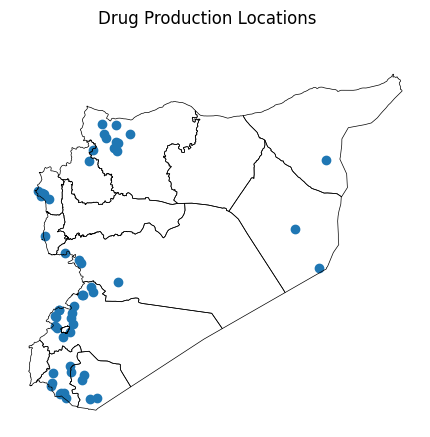

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
drug_gdf.plot(ax=ax)
syria_adm1.boundary.plot(ax=ax, color="black", linewidth=0.5)
plt.suptitle("Drug Production Locations")
ax.set_axis_off()

In [11]:
# Get the H3 index (resolution 8) for each point
drug_gdf["h3_index"] = drug_gdf.apply(
    lambda row: h3.latlng_to_cell(row.geometry.y, row.geometry.x, 8), axis=1
)

# Build hex polygons from each H3 cell
drug_gdf["hex_geometry"] = drug_gdf["h3_index"].apply(
    lambda cell: Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])
)

drug_h3 = drug_gdf.drop(columns=["geometry"]).copy()
drug_h3.rename(columns={"hex_geometry": "geometry"}, inplace=True)

# Create a GeoDataFrame with hexagonal geometries
drug_h3 = drug_gdf.set_geometry(gpd.GeoSeries(drug_h3["geometry"], crs="EPSG:4326"))

## Factory Locations

In [12]:
drug_h3.explore()

## Factory Neighbors

In [13]:
import pandas as pd

# Get unique factory H3 cells
factory_cells = set(drug_h3["h3_index"].unique())

# For each factory cell, get the k=1 ring (immediate neighbors) excluding the factory cell itself
neighbor_records = []
for cell in factory_cells:
    for neighbor in set(h3.grid_disk(cell, 1)) - {cell}:
        neighbor_records.append({"h3_index": neighbor, "factory_h3": cell})

neighbor_df = pd.DataFrame(neighbor_records).drop_duplicates(subset="h3_index")

# Build hex polygons for neighboring cells
neighbor_df["geometry"] = neighbor_df["h3_index"].apply(
    lambda cell: Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])
)

# Merge factory metadata onto neighbors via factory_h3 -> h3_index in drug_h3
meta_cols = [
    "h3_index",
    "Zone",
    "Address",
    "Factory_size",
    "Coordinates",
    "Yes_No",
    "Longitude",
    "Latitude",
]
factory_meta = drug_h3[meta_cols].drop_duplicates(subset="h3_index")
neighbor_df = neighbor_df.merge(
    factory_meta,
    left_on="factory_h3",
    right_on="h3_index",
    how="left",
    suffixes=("", "_factory"),
)
neighbor_df.drop(columns=["h3_index_factory"], inplace=True)

drug_h3_neighbors = gpd.GeoDataFrame(neighbor_df, geometry="geometry", crs="EPSG:4326")
drug_h3_neighbors.head()

,h3_index,factory_h3,geometry,Zone,Address,Factory_size,Coordinates,Yes_No,Longitude,Latitude
0,882da384a1fffff,882da384a9fffff,"POLYGON ((35.90081 35.5406, 35.89796 35.53613,...","Lattakia, Al Shelfatiyeh","Al Shelfatiyeh, Northern Al Haiyani road",Medium,"35.539371, 35.896352",No,35.896352,35.539371
1,882da384e7fffff,882da384a9fffff,"POLYGON ((35.8823 35.54026, 35.87946 35.53579,...","Lattakia, Al Shelfatiyeh","Al Shelfatiyeh, Northern Al Haiyani road",Medium,"35.539371, 35.896352",No,35.896352,35.539371
2,882da384adfffff,882da384a9fffff,"POLYGON ((35.8918 35.53602, 35.88896 35.53156,...","Lattakia, Al Shelfatiyeh","Al Shelfatiyeh, Northern Al Haiyani road",Medium,"35.539371, 35.896352",No,35.896352,35.539371
3,882da384abfffff,882da384a9fffff,"POLYGON ((35.90032 35.54941, 35.89748 35.54495...","Lattakia, Al Shelfatiyeh","Al Shelfatiyeh, Northern Al Haiyani road",Medium,"35.539371, 35.896352",No,35.896352,35.539371
4,882da384e3fffff,882da384a9fffff,"POLYGON ((35.88181 35.54907, 35.87897 35.54461...","Lattakia, Al Shelfatiyeh","Al Shelfatiyeh, Northern Al Haiyani road",Medium,"35.539371, 35.896352",No,35.896352,35.539371


In [14]:
drug_h3_neighbors.explore()

**There are 4 drug production sites that share one neighboring cell**
1. Rural Damascus, Falita -- the one close to the main road and the one close to Al Murjan for Aluminium
2. Rural Damascus Sargyahaya has two locations where they become each others neighbors i.e., one drug production factory is in the control group of the other. 
3. Rural Damascus Maddaya has two production locations that share a neighborig cell
4. Daraa, Nassib shares a neighboring cell

In [15]:
import numpy as np

utm_crs = syria_adm0.estimate_utm_crs()
syria_h3_utm = drug_h3.to_crs(utm_crs)
area = np.mean(syria_h3_utm["geometry"].area / 1000000)

In [16]:
from IPython.display import Markdown

Markdown(f"The average area of each grid is **{area:.2f} sq.km**")

The average area of each grid is **0.82 sq.km**

In [17]:
import os
from pathlib import Path

from getpass import getpass
from dotenv import dotenv_values
from blackmarble import BlackMarble

secrets_path = Path.home() / ".config" / "syria-economic-monitor" / "secrets.env"
secrets = dotenv_values(secrets_path)
blackmarble_token = secrets.get("BLACKMARBLE_TOKEN", "").strip()

if not blackmarble_token:
    blackmarble_token = getpass("Enter BlackMarble token (input hidden): ").strip()
    secrets_path.parent.mkdir(parents=True, exist_ok=True)
    secrets_path.write_text(f"BLACKMARBLE_TOKEN={blackmarble_token}\n")
    os.chmod(secrets_path, 0o600)

bm = BlackMarble(token=blackmarble_token)

In [19]:
# gdf_utm["buffer"] = gdf_utm.geometry.buffer(gdf_utm["buffer_radius"])
# gdf_buffer = gdf_utm.set_geometry("buffer").copy()
# gdf_buffer = gdf_buffer.to_crs(epsg=4326)
# gdf_buffer = gdf_buffer.set_geometry("buffer").rename_geometry("geometry")

In [20]:
drug_production_h3 = pd.concat([drug_h3, drug_h3_neighbors], ignore_index=True)

In [21]:
drug_production_h3.drop(columns=["hex_geometry"], inplace=True)

In [22]:
adm_mapping = (
    syria_adm1.sjoin(drug_production_h3, predicate="contains")[["h3_index", "NAME_EN"]]
    .drop_duplicates()
    .set_index("h3_index")
    .to_dict()["NAME_EN"]
)

In [26]:
# drug_production_h3 = drug_production_h3.to_crs(epsg=4326).copy()
# monthly_drug_5km = extract.bm_extract(
#     drug_production_h3,
#     "VNP46A3",
# pd.date_range("2023-01-01", "2026-01-01", freq="MS"),
# token = blackmarble_token,
# aggfunc=['sum', 'mean', 'min', 'max', 'std'],
# output_directory='../../data/ntl/raw/',
# output_skip_if_exists=True)

In [27]:
# monthly_drug_5km.to_csv('../../data/ntl/monthly_drug_h3_8_sites_only.csv', index=True)

monthly_drug_5km = pd.read_csv("../../data/ntl/monthly_drug_h3_8_sites_only.csv")

In [28]:
ntl_drugs = monthly_drug_5km.copy()

In [29]:
ntl_drugs["type"] = ntl_drugs["factory_h3"].apply(
    lambda x: "Neighbor" if pd.notnull(x) else "Factory"
)

In [30]:
# import pandas as pd
# for time_val in monthly_drug_5km['time'].values:
#     date_str = pd.Timestamp(time_val).strftime('%Y-%m')
#     monthly_drug_5km.sel(time=time_val)['NearNadir_Composite_Snow_Free'].rio.to_raster(
#         f'../../data/ntl/raw/monthly_raster_{date_str}.tif'
#     )

In [31]:
ntl_drugs_type_sum = (
    ntl_drugs.groupby(["type", "date", "Zone", "Address"])["ntl_sum"]
    .agg(["mean", "min", "max", "std"])
    .reset_index()
)
ntl_drugs_type_mean = (
    ntl_drugs.groupby(["type", "date", "Zone", "Address"])["ntl_mean"]
    .agg(["mean", "min", "max", "std"])
    .reset_index()
)

In [32]:
baseline = ntl_drugs[
    (ntl_drugs["date"] >= "2024-09-01") & (ntl_drugs["date"] < "2024-12-01")
]
baseline = baseline.groupby(["type", "h3_index"])["ntl_sum"].mean().reset_index()

baseline = baseline[["ntl_sum", "h3_index"]].set_index("h3_index").to_dict()["ntl_sum"]

ntl_drugs["baseline_ntl_sum"] = ntl_drugs["h3_index"].map(baseline)
ntl_drugs["pc_change_baseline"] = (
    100
    * (ntl_drugs["ntl_sum"] - ntl_drugs["baseline_ntl_sum"])
    / (ntl_drugs["baseline_ntl_sum"] + 1)
)

In [33]:
# Baseline: average of mean NTL over Sep–Nov 2024, per type/Zone/Address
baseline = ntl_drugs_type_mean[
    (ntl_drugs_type_mean["date"] >= "2024-09-01")
    & (ntl_drugs_type_mean["date"] < "2024-12-01")
]
baseline = (
    baseline.groupby(["type", "Zone", "Address"])["mean"]
    .mean()
    .reset_index()
    .rename(columns={"mean": "baseline_mean"})
)

ntl_drugs_type_mean = ntl_drugs_type_mean.merge(
    baseline, on=["type", "Zone", "Address"], how="left"
)
ntl_drugs_type_mean["pc_change_baseline"] = (
    100
    * (ntl_drugs_type_mean["mean"] - ntl_drugs_type_mean["baseline_mean"])
    / (ntl_drugs_type_mean["baseline_mean"] + 1)
)

In [34]:
# Baseline: average of mean NTL over Sep–Nov 2024, per type/Zone/Address
baseline = ntl_drugs_type_sum[
    (ntl_drugs_type_sum["date"] >= "2024-09-01")
    & (ntl_drugs_type_sum["date"] < "2024-12-01")
]
baseline = (
    baseline.groupby(["type", "Zone", "Address"])["mean"]
    .mean()
    .reset_index()
    .rename(columns={"mean": "baseline_mean"})
)

ntl_drugs_type_sum = ntl_drugs_type_sum.merge(
    baseline, on=["type", "Zone", "Address"], how="left"
)
ntl_drugs_type_sum["pc_change_baseline"] = (
    100
    * (ntl_drugs_type_sum["mean"] - ntl_drugs_type_sum["baseline_mean"])
    / (ntl_drugs_type_sum["baseline_mean"] + 1)
)

In [35]:
months_of_interest = [
    "2023-09-01",
    "2023-10-01",
    "2023-11-01",
    "2025-09-01",
    "2025-10-01",
    "2025-11-01",
]

# ntl_drugs_type_sum[ntl_drugs_type_sum['date'].isin(months_of_interest)]

## Difference between Percentage Change from Baseline betwen Factories and Neighbors

Baseline: 2024 September to 2024 November

In [36]:
import altair as alt
import pandas as pd

# WBG colors
COLOR_FACTORY = "#0071BC"
COLOR_NEIGHBOR = "#FF9800"

# Define periods
period_2023 = ["2023-09-01", "2023-10-01", "2023-11-01"]
period_2025 = ["2025-09-01", "2025-10-01", "2025-11-01"]

df = ntl_drugs_type_sum.copy()
df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")

# Build records per location, period, and type
locations = df.groupby(["Zone", "Address"]).groups.keys()
records = []
for zone, addr in locations:
    loc = df[(df["Zone"] == zone) & (df["Address"] == addr)]
    raw_label = f"{zone} – {addr}" if pd.notna(addr) and str(addr).strip() else zone
    label = raw_label[:30] + "..." if len(raw_label) > 30 else raw_label
    for period_dates, period_label in [
        (period_2023, "Sep–Nov 2023"),
        (period_2025, "Sep–Nov 2025"),
    ]:
        for t in ["Factory", "Neighbor"]:
            val = loc[(loc["type"] == t) & (loc["date"].isin(period_dates))][
                "pc_change_baseline"
            ].mean()
            records.append(
                {"location": label, "period": period_label, "type": t, "val": val}
            )

plot_df = pd.DataFrame(records)

bars = (
    alt.Chart(plot_df)
    .mark_bar()
    .encode(
        x=alt.X(
            "period:N",
            title=None,
            sort=["Sep–Nov 2023", "Sep–Nov 2025"],
            axis=alt.Axis(labelAngle=-30),
        ),
        xOffset=alt.XOffset("type:N", sort=["Factory", "Neighbor"]),
        y=alt.Y("val:Q", title="% change from baseline"),
        color=alt.Color(
            "type:N",
            scale=alt.Scale(
                domain=["Factory", "Neighbor"], range=[COLOR_FACTORY, COLOR_NEIGHBOR]
            ),
            legend=alt.Legend(title=None, orient="top"),
        ),
    )
)

rule = (
    alt.Chart(plot_df)
    .mark_rule(color="black", strokeWidth=0.5)
    .encode(
        y=alt.datum(0),
    )
)

chart = (
    alt.layer(bars, rule)
    .properties(
        width=120,
        height=150,
    )
    .facet(
        facet=alt.Facet(
            "location:N",
            title=None,
            header=alt.Header(
                labelFontSize=10, labelFontWeight="bold", labelAnchor="start"
            ),
        ),
        columns=3,
    )
    .resolve_scale(y="independent")
    .properties(
        title=alt.Title(
            text="Factory vs Neighbor % Change in NTL by Location & Period",
            anchor="start",
            fontSize=14,
        )
    )
    .configure(font="Open Sans")
    .configure_view(strokeWidth=0)
)

chart

alt.FacetChart(...)

In [84]:
pivot = ntl_drugs_type_sum.pivot_table(
    index=["Zone", "Address", "date"],
    columns="type",
    values=["mean", "pc_change_baseline", "baseline_mean"],
).reset_index()

# Flatten multi-level column headers
pivot.columns = [
    "_".join(col).strip("_") if col[1] else col[0] for col in pivot.columns
]
pivot.to_csv("../../data/ntl/ntl_drugs_factory_neighbor_pivot.csv", index=False)
pivot

,Zone,Address,date,baseline_mean_Factory,baseline_mean_Neighbor,mean_Factory,mean_Neighbor,pc_change_baseline_Factory,pc_change_baseline_Neighbor
0,"Al Hassakah, Al Shadadi, Khwaibeirah","Khwaibira, Close to the road of Khwaibira link...",2023-01-01,0.000000,0.029118,0.000000,0.000000,0.000000,-2.829386
1,"Al Hassakah, Al Shadadi, Khwaibeirah","Khwaibira, Close to the road of Khwaibira link...",2023-02-01,0.000000,0.029118,0.575226,0.625450,57.522595,57.945981
2,"Al Hassakah, Al Shadadi, Khwaibeirah","Khwaibira, Close to the road of Khwaibira link...",2023-03-01,0.000000,0.029118,0.000000,0.000000,0.000000,-2.829386
3,"Al Hassakah, Al Shadadi, Khwaibeirah","Khwaibira, Close to the road of Khwaibira link...",2023-04-01,0.000000,0.029118,0.000000,0.000000,0.000000,-2.829386
4,"Al Hassakah, Al Shadadi, Khwaibeirah","Khwaibira, Close to the road of Khwaibira link...",2023-05-01,0.000000,0.029118,1.059984,1.524259,105.998445,145.283787
...,...,...,...,...,...,...,...,...,...
1919,"Tartous, Al Shikh Saad","Al Shikh Saad, Al Sahem Road.",2025-09-01,12.250335,12.432335,18.117785,16.446441,44.281518,29.883900
1920,"Tartous, Al Shikh Saad","Al Shikh Saad, Al Sahem Road.",2025-10-01,12.250335,12.432335,17.358829,15.453610,38.553694,22.492552
1921,"Tartous, Al Shikh Saad","Al Shikh Saad, Al Sahem Road.",2025-11-01,12.250335,12.432335,20.483466,21.420842,62.135263,66.916938
1922,"Tartous, Al Shikh Saad","Al Shikh Saad, Al Sahem Road.",2025-12-01,12.250335,12.432335,18.201165,20.441956,44.910787,59.629402


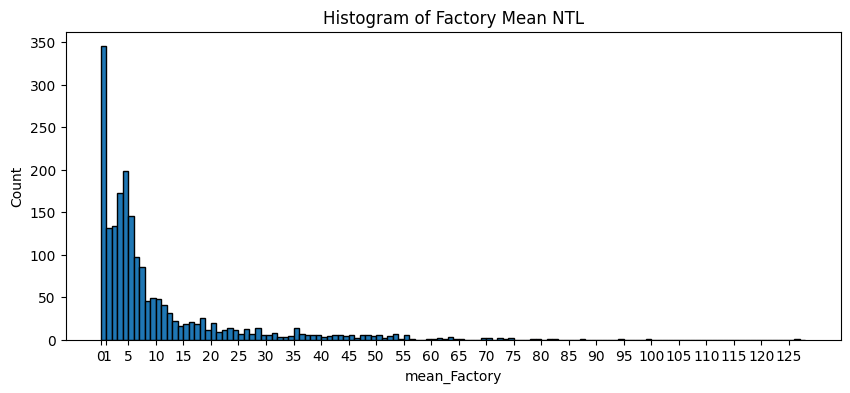

In [56]:
series = pivot["mean_Factory"].dropna()
max_edge = max(1, int(np.ceil(series.max())))
bins = [0, 1] + list(range(2, max_edge + 2))

tick_positions = [0, 1] + list(range(5, max_edge + 2, 5))

plt.figure(figsize=(10, 4))
plt.hist(series, bins=bins, edgecolor="black")
plt.xticks(tick_positions)
plt.xlabel("mean_Factory")
plt.ylabel("Count")
plt.title("Histogram of Factory Mean NTL")
plt.show()

In [81]:
pivot[pivot["mean_Factory"] == 0]

,Zone,Address,date,mean_Factory,mean_Neighbor,pc_change_baseline_Factory,pc_change_baseline_Neighbor
0,"Al Hassakah, Al Shadadi, Khwaibeirah","Khwaibira, Close to the road of Khwaibira link...",2023-01-01,0.0,0.000000,0.000000,-2.829386
2,"Al Hassakah, Al Shadadi, Khwaibeirah","Khwaibira, Close to the road of Khwaibira link...",2023-03-01,0.0,0.000000,0.000000,-2.829386
3,"Al Hassakah, Al Shadadi, Khwaibeirah","Khwaibira, Close to the road of Khwaibira link...",2023-04-01,0.0,0.000000,0.000000,-2.829386
6,"Al Hassakah, Al Shadadi, Khwaibeirah","Khwaibira, Close to the road of Khwaibira link...",2023-07-01,0.0,0.169238,0.000000,13.615615
7,"Al Hassakah, Al Shadadi, Khwaibeirah","Khwaibira, Close to the road of Khwaibira link...",2023-08-01,0.0,0.000000,0.000000,-2.829386
...,...,...,...,...,...,...,...
1704,"Rural Damascus, Rankous","Rankous, the eastern neighborhood, Close to th...",2023-03-01,0.0,0.097493,-62.185374,-40.468168
1714,"Rural Damascus, Rankous","Rankous, the eastern neighborhood, Close to th...",2024-01-01,0.0,0.169379,-62.185374,-36.568787
1715,"Rural Damascus, Rankous","Rankous, the eastern neighborhood, Close to th...",2024-02-01,0.0,0.085152,-62.185374,-41.137562
1724,"Rural Damascus, Rankous","Rankous, the eastern neighborhood, Close to th...",2024-11-01,0.0,0.242236,-62.185374,-32.616804


In [38]:
# ntl_drugs['Zone'].replace({'Rural Aleppo, Afrin, Al OqaibahAl Oqaibah, the eastern enterance of the village, Al Bassoutah road': 'Rural Aleppo, Afrin, Al Oqaibah'}, inplace=True)

In [39]:
ntl_drugs = ntl_drugs[ntl_drugs["ntl_sum"] > 1]

### Identified Limitations

It was seen that June and July of 2025 have high spikes in lights in June and July, so they were removed from the maps as months of interest. This is because the quality of observations that fed into those months of data seems faulty. We're still looking into how to best deal with this data discrepancy. 

In [40]:
drug_adm_mapping = drug_gdf.sjoin(syria_adm1, predicate="within")[
    ["Zone", "Address", "NAME_EN"]
].drop_duplicates()

In [41]:
ntl_drugs_admin = ntl_drugs_type_sum.merge(
    drug_adm_mapping, on=["Zone", "Address"], how="left"
)
ntl_drugs_admin = (
    ntl_drugs_admin.groupby(["date", "NAME_EN", "type"])["mean"].mean().reset_index()
)

In [42]:
baseline_admin = ntl_drugs_admin[
    (ntl_drugs_admin["date"] >= "2024-09-01") & (ntl_drugs_admin["date"] < "2024-12-01")
]
baseline_admin = baseline_admin.groupby("NAME_EN")["mean"].mean().reset_index()
baseline_admin = (
    baseline_admin[["mean", "NAME_EN"]].set_index("NAME_EN").to_dict()["mean"]
)

ntl_drugs_admin["baseline_ntl_sum"] = ntl_drugs_admin["NAME_EN"].map(baseline_admin)
ntl_drugs_admin["pc_change_baseline"] = (
    100
    * (ntl_drugs_admin["mean"] - ntl_drugs_admin["baseline_ntl_sum"])
    / (ntl_drugs_admin["baseline_ntl_sum"] + 1)
)

In [43]:
ntl_drugs_admin["pc_change_treatment_control"] = ntl_drugs_admin.groupby(
    ["date", "NAME_EN"]
)["pc_change_baseline"].transform(lambda x: (x - x.shift(1)))

In [87]:
pivot_admin = ntl_drugs_admin.pivot_table(
    index=["NAME_EN", "date"],
    columns="type",
    values=["mean", "pc_change_baseline", "baseline_ntl_sum"],
).reset_index()

pivot_admin.columns = [
    "_".join(col).strip("_") if col[1] else col[0] for col in pivot_admin.columns
]
pivot_admin.to_csv(
    "../../data/ntl/ntl_drugs_admin_factory_neighbor_pivot.csv", index=False
)
pivot_admin

,NAME_EN,date,baseline_ntl_sum_Factory,baseline_ntl_sum_Neighbor,mean_Factory,mean_Neighbor,pc_change_baseline_Factory,pc_change_baseline_Neighbor
0,Al-Hasakeh,2023-01-01,0.014559,0.014559,0.000000,0.000000,-1.434994,-1.434994
1,Al-Hasakeh,2023-02-01,0.014559,0.014559,0.575226,0.625450,55.262155,60.212496
2,Al-Hasakeh,2023-03-01,0.014559,0.014559,0.000000,0.000000,-1.434994,-1.434994
3,Al-Hasakeh,2023-04-01,0.014559,0.014559,0.000000,0.000000,-1.434994,-1.434994
4,Al-Hasakeh,2023-05-01,0.014559,0.014559,1.059984,1.524259,103.042380,148.803594
...,...,...,...,...,...,...,...,...
365,Tartous,2025-09-01,12.341335,12.341335,18.117785,16.446441,43.297389,30.769825
366,Tartous,2025-10-01,12.341335,12.341335,17.358829,15.453610,37.608633,23.328062
367,Tartous,2025-11-01,12.341335,12.341335,20.483466,21.420842,61.029354,68.055462
368,Tartous,2025-12-01,12.341335,12.341335,18.201165,20.441956,43.922365,60.718218


In [46]:
import altair as alt
import pandas as pd

# WBG colors
COLOR_FACTORY = "#0071BC"
COLOR_NEIGHBOR = "#FF9800"

# Define periods
period_2023 = ["2023-09-01", "2023-10-01", "2023-11-01"]
period_2025 = ["2025-09-01", "2025-10-01", "2025-11-01"]

df = ntl_drugs_admin.copy()
df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")

# Build records per admin region, period, and type
records = []
for region in df["NAME_EN"].unique():
    loc = df[df["NAME_EN"] == region]
    for period_dates, period_label in [
        (period_2023, "Sep–Nov 2023"),
        (period_2025, "Sep–Nov 2025"),
    ]:
        for t in ["Factory", "Neighbor"]:
            val = loc[(loc["type"] == t) & (loc["date"].isin(period_dates))][
                "pc_change_baseline"
            ].mean()
            records.append(
                {"region": region, "period": period_label, "type": t, "val": val}
            )

plot_df = pd.DataFrame(records)

bars = (
    alt.Chart(plot_df)
    .mark_bar()
    .encode(
        x=alt.X(
            "period:N",
            title=None,
            sort=["Sep–Nov 2023", "Sep–Nov 2025"],
            axis=alt.Axis(labelAngle=-30),
        ),
        xOffset=alt.XOffset("type:N", sort=["Factory", "Neighbor"]),
        y=alt.Y("val:Q", title="% change from baseline"),
        color=alt.Color(
            "type:N",
            scale=alt.Scale(
                domain=["Factory", "Neighbor"], range=[COLOR_FACTORY, COLOR_NEIGHBOR]
            ),
            legend=alt.Legend(title=None, orient="top"),
        ),
    )
)

rule = (
    alt.Chart(plot_df)
    .mark_rule(color="black", strokeWidth=0.5)
    .encode(
        y=alt.datum(0),
    )
)

chart = (
    alt.layer(bars, rule)
    .properties(
        width=120,
        height=150,
    )
    .facet(
        facet=alt.Facet(
            "region:N",
            title=None,
            header=alt.Header(
                labelFontSize=11, labelFontWeight="bold", labelAnchor="start"
            ),
        ),
        columns=4,
    )
    .resolve_scale(y="independent")
    .properties(
        title=alt.Title(
            text="Factory vs Neighbor % Change in NTL by Admin Region & Period",
            anchor="start",
            fontSize=14,
        )
    )
    .configure(font="Open Sans")
    .configure_view(strokeWidth=0)
)

chart

alt.FacetChart(...)